# 03 - Análisis Exploratorio de Datos (EDA)

Este notebook contiene el análisis exploratorio de los datasets limpios generados en `02_cleaning.ipynb`.

El objetivo es entender la estructura de los datos, revisar la calidad de las variables principales e identificar primeros patrones sobre roles, empresas, ubicaciones, modalidad de trabajo, salarios, skills y tecnologías.

El EDA se plantea como una fase de diagnóstico: no busca cerrar conclusiones definitivas, sino dejar una base clara para las visualizaciones y el análisis posterior.

## 1. Objetivo

En este notebook se trabajará principalmente con `jobs_all_clean.csv`, porque es el dataset unificado de ofertas generado en la fase de limpieza.

También se usarán datasets auxiliares para contrastar información:

- `jobs_clean.csv`: ofertas originales relacionadas con datos.
- `tecno_jobs_clean.csv`: ofertas tecnológicas de TecnoEmpleo con columnas ya unificadas.
- `job_skills_long.csv`: skills de ofertas en formato largo.
- `technology_rankings.csv`: rankings de tecnologías procedentes de Stack Overflow.

Las preguntas principales son:

- ¿Qué tamaño y estructura tienen los datasets limpios?
- ¿Qué columnas tienen más valores nulos?
- ¿Qué roles, empresas y ubicaciones aparecen con mayor frecuencia?
- ¿Qué modalidades de trabajo predominan?
- ¿Cuánta información salarial hay y cómo se distribuye?
- ¿Qué skills y tecnologías destacan en las fuentes disponibles?

## 2. Imports y configuración inicial

Se importan las librerías necesarias, se configuran opciones de visualización y se definen las rutas del proyecto.

Las variables, funciones y estructuras del código se nombran en inglés para mantener consistencia con el cleaning. Los comentarios del código incluyen español e inglés.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configurar pandas y graficos / Configure pandas and plots
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", palette="Set2")

# Definir rutas del proyecto / Define project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_CLEAN = PROJECT_ROOT / "data" / "clean"

print("Raiz del proyecto:", PROJECT_ROOT)
print("Carpeta de datos limpios:", DATA_CLEAN)

Raiz del proyecto: C:\Users\User\OneDrive\Documentos\BOOTCAMP IA\Proyecto1-modulo2\proyecto-eda-roles-datos
Carpeta de datos limpios: C:\Users\User\OneDrive\Documentos\BOOTCAMP IA\Proyecto1-modulo2\proyecto-eda-roles-datos\data\clean


## 3. Carga de datasets limpios

Se cargan los archivos generados por el notebook de cleaning. Si alguna ruta falla, conviene ejecutar primero `02_cleaning.ipynb` para regenerar los CSV limpios.

In [2]:
# Cargar datasets limpios / Load clean datasets
jobs_clean = pd.read_csv(DATA_CLEAN / "jobs_clean.csv")
tecno_jobs_clean = pd.read_csv(DATA_CLEAN / "tecno_jobs_clean.csv")
jobs_all_clean = pd.read_csv(DATA_CLEAN / "jobs_all_clean.csv")
job_skills_long = pd.read_csv(DATA_CLEAN / "job_skills_long.csv")
stack_tech_columns_clean = pd.read_csv(DATA_CLEAN / "stack_tech_columns_clean.csv")
technologies_clean_long_format = pd.read_csv(DATA_CLEAN / "technologies_clean_long_format.csv")
technology_rankings = pd.read_csv(DATA_CLEAN / "technology_rankings.csv")
technology_rankings_used = pd.read_csv(DATA_CLEAN / "technology_rankings_used.csv")
technology_rankings_wanted = pd.read_csv(DATA_CLEAN / "technology_rankings_wanted.csv")
cleaning_validation_summary = pd.read_csv(DATA_CLEAN / "cleaning_validation_summary.csv")
clean_datasets_dictionary = pd.read_csv(DATA_CLEAN / "clean_datasets_dictionary.csv")

# Crear copia de trabajo para EDA / Create working copy for EDA
jobs_eda = jobs_all_clean.copy()

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


## 4. Funciones auxiliares para el EDA

Estas funciones permiten reutilizar comprobaciones habituales: resumen de columnas, valores nulos, tablas de frecuencia y gráficos básicos.

In [3]:
def build_dataset_summary(datasets):
    """
    ES: Crea un resumen con filas, columnas y nombres de variables.
    EN: Builds a summary with rows, columns and variable names.
    """
    summary_rows = []

    for dataset_name, dataframe in datasets.items():
        summary_rows.append({
            "dataset": dataset_name,
            "rows": dataframe.shape[0],
            "columns": dataframe.shape[1],
            "column_names": ", ".join(dataframe.columns)
        })

    return pd.DataFrame(summary_rows)


def build_missing_summary(dataframe):
    """
    ES: Calcula valores nulos por columna.
    EN: Calculates missing values by column.
    """
    missing_summary = pd.DataFrame({
        "column": dataframe.columns,
        "missing_values": dataframe.isna().sum().values,
        "missing_pct": dataframe.isna().mean().mul(100).round(2).values,
        "dtype": dataframe.dtypes.astype(str).values
    })

    return missing_summary.sort_values("missing_pct", ascending=False).reset_index(drop=True)


def show_top_values(dataframe, column, top_n=15):
    """
    ES: Muestra los valores mas frecuentes de una columna.
    EN: Shows the most frequent values in a column.
    """
    if column not in dataframe.columns:
        print(f"La columna {column} no existe en el dataset.")
        return pd.DataFrame()

    top_values = (
        dataframe[column]
        .dropna()
        .astype(str)
        .value_counts()
        .head(top_n)
        .rename_axis(column)
        .reset_index(name="count")
    )

    display(top_values)
    return top_values


def plot_top_values(dataframe, column, title, top_n=15, figsize=(10, 5)):
    """
    ES: Grafica los valores mas frecuentes de una columna.
    EN: Plots the most frequent values in a column.
    """
    if column not in dataframe.columns:
        print(f"La columna {column} no existe en el dataset.")
        return

    plot_data = (
        dataframe[column]
        .dropna()
        .astype(str)
        .value_counts()
        .head(top_n)
        .sort_values(ascending=True)
    )

    if plot_data.empty:
        print(f"No hay datos suficientes para graficar {column}.")
        return

    plt.figure(figsize=figsize)
    sns.barplot(x=plot_data.values, y=plot_data.index, orient="h")
    plt.title(title)
    plt.xlabel("Numero de registros")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()


def normalize_text_value(value):
    """
    ES: Normaliza texto para comparaciones simples.
    EN: Normalizes text for simple comparisons.
    """
    if pd.isna(value):
        return np.nan

    return " ".join(str(value).lower().strip().split())

## 5. Revisión de estructura

Antes de analizar patrones, se revisa el tamaño de cada archivo limpio y se comprueba que los nombres de columnas ya están unificados respecto al cleaning.

In [4]:
datasets = {
    "jobs_clean": jobs_clean,
    "tecno_jobs_clean": tecno_jobs_clean,
    "jobs_all_clean": jobs_all_clean,
    "job_skills_long": job_skills_long,
    "stack_tech_columns_clean": stack_tech_columns_clean,
    "technologies_clean_long_format": technologies_clean_long_format,
    "technology_rankings": technology_rankings,
    "technology_rankings_used": technology_rankings_used,
    "technology_rankings_wanted": technology_rankings_wanted
}

# Resumir datasets disponibles / Summarize available datasets
dataset_summary = build_dataset_summary(datasets)
display(dataset_summary)

,dataset,rows,columns,column_names
0,jobs_clean,944,16,"job_title, seniority_level, status, company, l..."
1,tecno_jobs_clean,600,11,"job_title, company, location, salary, job_type..."
2,jobs_all_clean,1542,17,"job_id, job_title, company, location, salary, ..."
3,job_skills_long,4176,4,"job_id, job_title, source_dataset, skill"
4,stack_tech_columns_clean,49191,13,"response_id, language_have_worked_with, langua..."
5,technologies_clean_long_format,1176875,4,"response_id, technology, category, type"
6,technology_rankings,372,4,"category, type, technology, count"
7,technology_rankings_used,186,4,"category, type, technology, count"
8,technology_rankings_wanted,186,4,"category, type, technology, count"


In [5]:
# Revisar validaciones del cleaning / Review cleaning validations
display(cleaning_validation_summary)

affected_checks = cleaning_validation_summary[cleaning_validation_summary["passed"] == False]

if affected_checks.empty:
    print("Todas las validaciones del cleaning estan correctas.")
else:
    print("Hay validaciones del cleaning que requieren revision:")
    display(affected_checks)

,check,passed,detail
0,jobs_all_clean_required_columns,True,Columnas faltantes / Missing columns: []
1,jobs_all_clean_not_empty,True,Filas / Rows: 1542
2,job_id_unique,True,job_id es único / job_id is unique
3,tecno_columns_standardized,True,Columnas de tecno_jobs_clean / tecno_jobs_clea...
4,stack_columns_snake_case,True,Columnas de stack_tech_columns_clean / stack_t...
5,technologies_response_id_standardized,True,Columnas de df_tech_clean / df_tech_clean colu...
6,salary_clean_numeric,True,salary_clean debe ser numérica / salary_clean ...
7,is_remote_boolean,True,is_remote debe contener booleanos / is_remote ...
8,job_skills_long_has_expected_columns,True,"Columnas / Columns: ['job_id', 'job_title', 's..."
9,expected_clean_files_exist,True,Archivos faltantes / Missing files: []


Todas las validaciones del cleaning estan correctas.


## 6. Dataset principal para el análisis

`jobs_all_clean.csv` será el dataset principal del EDA porque une las fuentes de ofertas bajo una misma estructura. Primero se revisan sus columnas, tipos de datos y primeras filas.

In [6]:
# Vista inicial del dataset principal / Initial view of the main dataset
print("Dimension de jobs_all_clean:", jobs_eda.shape)
print("Columnas:")
print(jobs_eda.columns.tolist())

display(jobs_eda.head())

Dimension de jobs_all_clean: (1542, 17)
Columnas:
['job_id', 'job_title', 'company', 'location', 'salary', 'job_type', 'post_date', 'link', 'skills', 'industry', 'seniority_level', 'source_dataset', 'salary_clean', 'location_clean', 'city_clean', 'is_remote', 'salary_clean_outlier']


,job_id,job_title,company,location,salary,job_type,post_date,link,skills,industry,seniority_level,source_dataset,salary_clean,location_clean,city_clean,is_remote,salary_clean_outlier
0,job_00001,data scientist,company_003,"Grapevine, TX . Hybrid","€100,472 - €200,938",NaN,17 days ago,NaN,"['spark', 'r', 'python', 'scala', 'machine lea...",Retail,senior,df_jobs,150705.0,"Grapevine, TX . Hybrid",Grapevine,False,False
1,job_00002,data scientist,company_005,"Fort Worth, TX . Hybrid","€118,733",NaN,15 days ago,NaN,"['spark', 'r', 'python', 'sql', 'machine learn...",Manufacturing,lead,df_jobs,118733.0,"Fort Worth, TX . Hybrid",Fort Worth,False,False
2,job_00003,data scientist,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...","€94,987 - €159,559",NaN,a month ago,NaN,"['aws', 'git', 'python', 'docker', 'sql', 'mac...",Technology,senior,df_jobs,127273.0,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",Austin,False,False
3,job_00004,data scientist,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...","€112,797 - €194,402",NaN,8 days ago,NaN,"['sql', 'r', 'python']",Technology,senior,df_jobs,153599.5,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",Chicago,False,False
4,job_00005,data scientist,company_009,On-site,"€114,172 - €228,337",NaN,3 days ago,NaN,[],Finance,NaN,df_jobs,171254.5,On-site,On-site,False,False


In [7]:
# Tipos de datos del dataset principal / Data types of the main dataset
jobs_dtypes = (
    jobs_eda
    .dtypes
    .astype(str)
    .reset_index()
    .rename(columns={"index": "column", 0: "dtype"})
)

display(jobs_dtypes)

,column,dtype
0,job_id,str
1,job_title,str
2,company,str
3,location,str
4,salary,str
5,job_type,str
6,post_date,str
7,link,str
8,skills,str
9,industry,str


## 7. Valores nulos

Se analizan los valores nulos del dataset unificado. Esto ayuda a saber qué variables son más fiables para el análisis y cuáles deben tratarse con cautela.

In [8]:
# Resumen de nulos del dataset principal / Missing-value summary for the main dataset
missing_jobs = build_missing_summary(jobs_eda)
display(missing_jobs)

,column,missing_values,missing_pct,dtype
0,job_type,1155,74.90,str
1,link,942,61.09,str
2,seniority_level,660,42.80,str
3,industry,600,38.91,str
4,skills,600,38.91,str
5,salary,471,30.54,str
6,salary_clean,471,30.54,float64
7,city_clean,183,11.87,str
8,location,183,11.87,str
9,location_clean,183,11.87,str


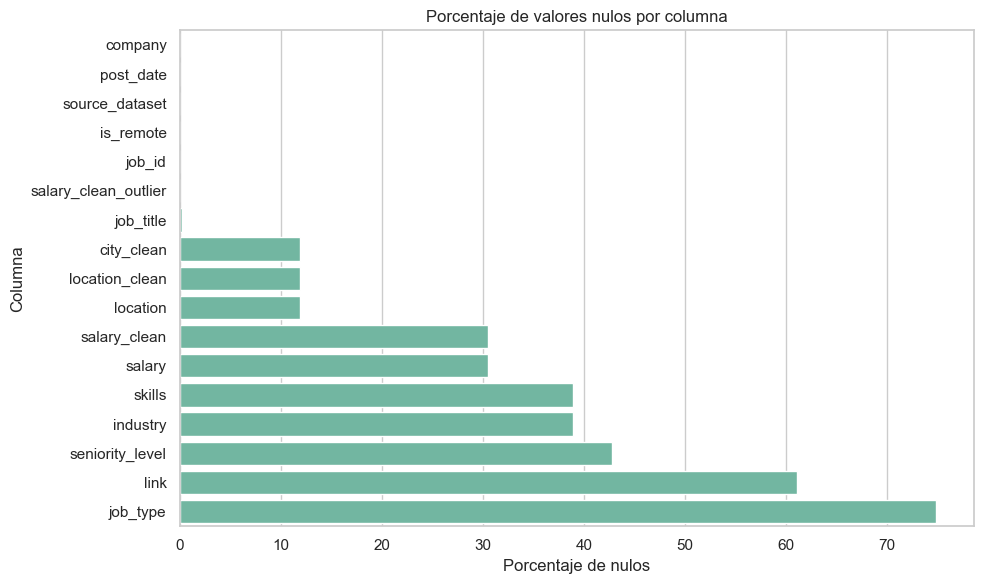

In [9]:
# Graficar porcentaje de nulos / Plot missing-value percentage
plot_data = missing_jobs.sort_values("missing_pct", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x="missing_pct", y="column")
plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Porcentaje de nulos")
plt.ylabel("Columna")
plt.tight_layout()
plt.show()

## 8. Cobertura por fuente

Se revisa cuántas ofertas aporta cada fuente. Esta comprobación es importante porque una fuente con muchas más filas puede dominar los resultados agregados.

,source_dataset,job_count,job_pct
0,df_jobs,942,61.09
1,df_tecno,600,38.91


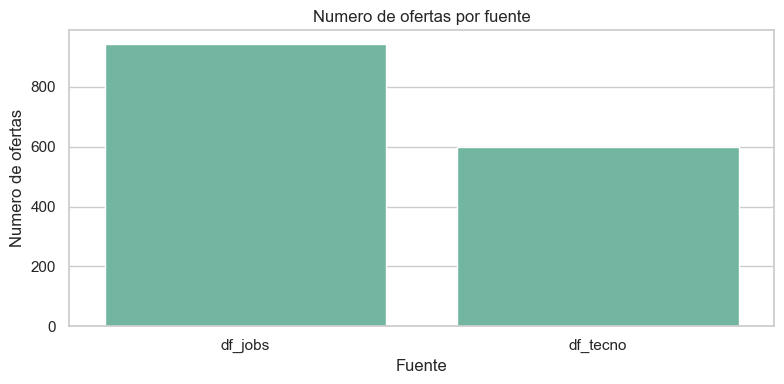

In [10]:
# Distribucion por fuente / Source distribution
source_distribution = (
    jobs_eda["source_dataset"]
    .value_counts(dropna=False)
    .rename_axis("source_dataset")
    .reset_index(name="job_count")
)

source_distribution["job_pct"] = (
    source_distribution["job_count"] / source_distribution["job_count"].sum() * 100
).round(2)

display(source_distribution)

plt.figure(figsize=(8, 4))
sns.barplot(data=source_distribution, x="source_dataset", y="job_count")
plt.title("Numero de ofertas por fuente")
plt.xlabel("Fuente")
plt.ylabel("Numero de ofertas")
plt.tight_layout()
plt.show()

## 9. Análisis de puestos

Se revisan los puestos más frecuentes y se crea una clasificación aproximada por familias de rol. Esta clasificación no sustituye a una taxonomía profesional completa, pero ayuda a leer tendencias generales.

,job_title,count
0,data scientist,856
1,machine learning engineer,78
2,data engineer,4
3,Project Manager,4
4,Electromecánico/a,4
5,Analista Programador/a .NET,3
6,Software Development Engineer,2
7,Programador/a PLC,2
8,Programador/a Cobol,2
9,IT Support Technician,2


C:\Users\User\AppData\Local\Temp\ipykernel_31448\2869323902.py:84: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.tight_layout()
) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\OneDrive\Documentos\BOOTCAMP IA\Proyecto1-modulo2\proyecto-eda-roles-datos\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


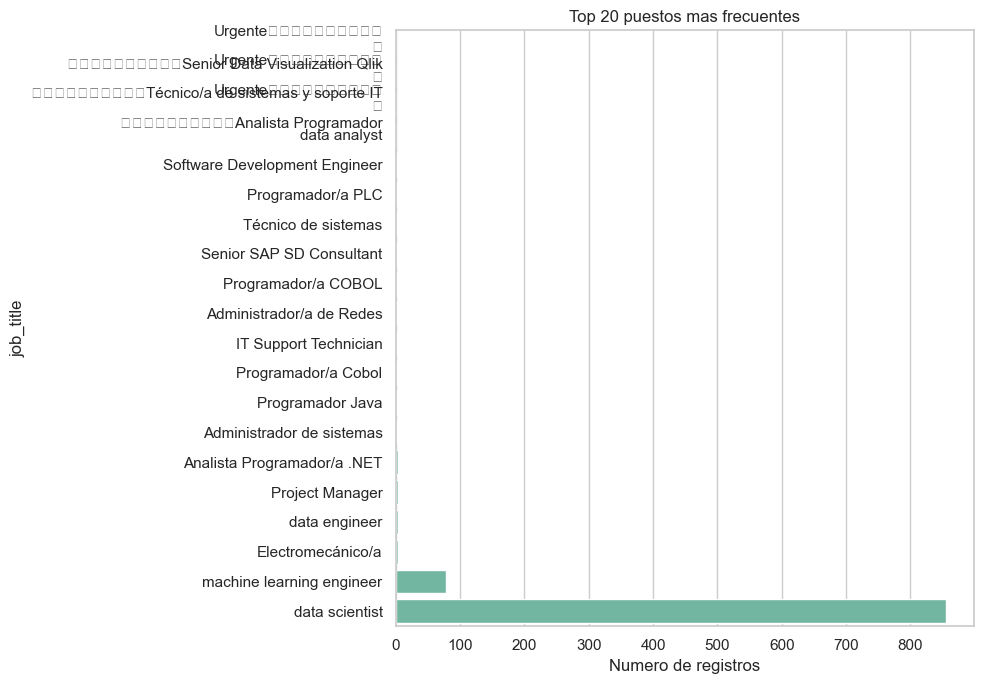

In [11]:
# Puestos mas frecuentes / Most frequent job titles
top_job_titles = show_top_values(jobs_eda, "job_title", top_n=20)
plot_top_values(jobs_eda, "job_title", "Top 20 puestos mas frecuentes", top_n=20, figsize=(10, 7))

,job_family,job_count,job_pct
0,data_science_ai,942,61.09
1,other,228,14.79
2,software_development,203,13.16
3,management_architecture,55,3.57
4,systems_cloud_devops,49,3.18
5,data_analysis_bi,20,1.30
6,cybersecurity,17,1.10
7,data_engineering,16,1.04
8,qa_testing,9,0.58
9,unknown,3,0.19


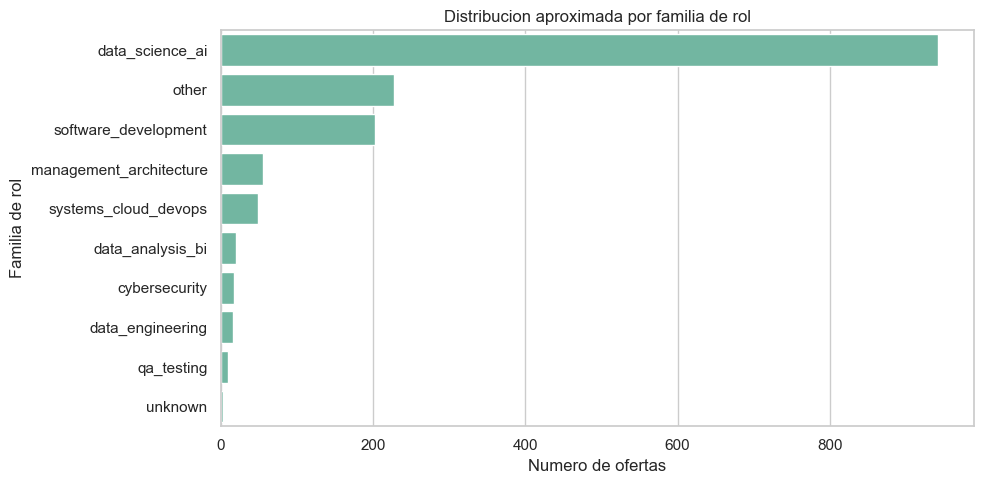

In [12]:
def classify_job_family(job_title):
    """
    ES: Clasifica un puesto en familias generales usando palabras clave.
    EN: Classifies a job title into broad families using keywords.
    """
    title = normalize_text_value(job_title)

    if pd.isna(title):
        return "unknown"

    if any(keyword in title for keyword in ["data scientist", "machine learning", "ml engineer", "ai engineer", "inteligencia artificial"]):
        return "data_science_ai"
    if any(keyword in title for keyword in ["data analyst", "analyst", "business intelligence", "bi ", "power bi", "qlik", "tableau"]):
        return "data_analysis_bi"
    if any(keyword in title for keyword in ["data engineer", "big data", "etl", "analytics engineer"]):
        return "data_engineering"
    if any(keyword in title for keyword in ["developer", "programador", "desarrollador", "software", "frontend", "backend", "fullstack", "java", ".net", "python engineer"]):
        return "software_development"
    if any(keyword in title for keyword in ["qa", "tester", "testing", "quality"]):
        return "qa_testing"
    if any(keyword in title for keyword in ["devops", "sistemas", "system", "cloud", "infrastructure", "network"]):
        return "systems_cloud_devops"
    if any(keyword in title for keyword in ["security", "cyber", "ciberseguridad"]):
        return "cybersecurity"
    if any(keyword in title for keyword in ["lead", "manager", "jefe", "project", "arquitecto", "architect"]):
        return "management_architecture"

    return "other"


# Crear familia de rol para el EDA / Create job family for EDA
jobs_eda["job_family"] = jobs_eda["job_title"].apply(classify_job_family)

job_family_distribution = (
    jobs_eda["job_family"]
    .value_counts()
    .rename_axis("job_family")
    .reset_index(name="job_count")
)

job_family_distribution["job_pct"] = (
    job_family_distribution["job_count"] / job_family_distribution["job_count"].sum() * 100
).round(2)

display(job_family_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=job_family_distribution, x="job_count", y="job_family")
plt.title("Distribucion aproximada por familia de rol")
plt.xlabel("Numero de ofertas")
plt.ylabel("Familia de rol")
plt.tight_layout()
plt.show()

## 10. Empresas

Se revisan las empresas con más ofertas publicadas. Si pocas empresas concentran muchas ofertas, las conclusiones pueden reflejar más las necesidades de esas empresas que las del mercado completo.

,company,count
0,Michael Page,66
1,Serem,42
2,Page Personnel,40
3,HAYS,40
4,Baoss,36
5,company_134,30
6,GMV,26
7,UST,25
8,Randstad ES,25
9,company_003,24


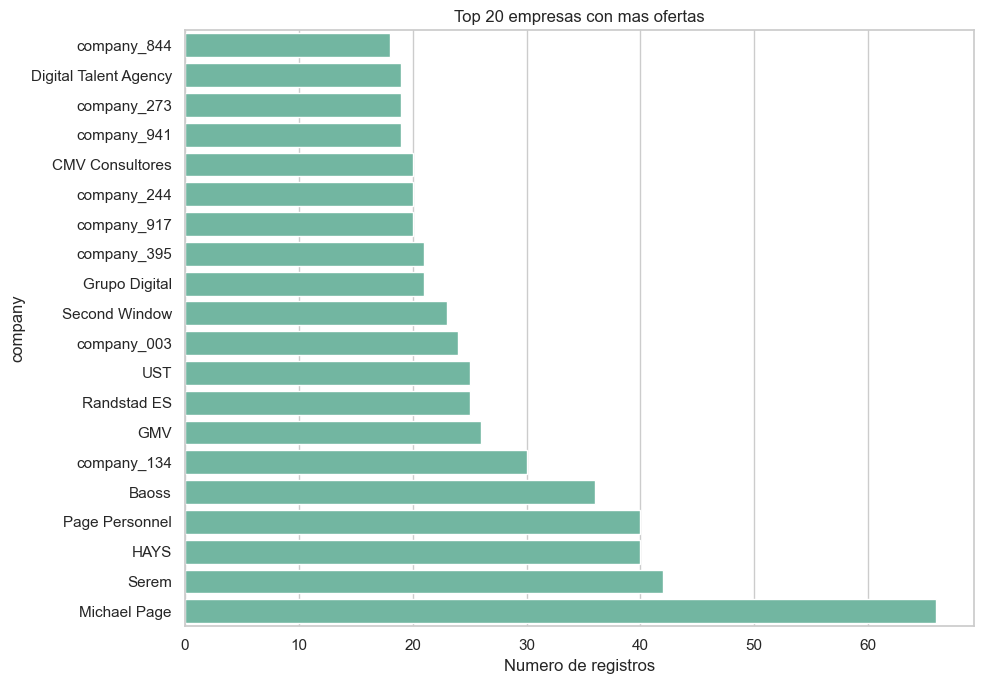

In [13]:
# Empresas mas frecuentes / Most frequent companies
top_companies = show_top_values(jobs_eda, "company", top_n=20)
plot_top_values(jobs_eda, "company", "Top 20 empresas con mas ofertas", top_n=20, figsize=(10, 7))

In [14]:
# Concentracion de ofertas por empresa / Job concentration by company
company_counts = jobs_eda["company"].dropna().value_counts()
company_concentration = pd.DataFrame({
    "metric": ["companies", "top_5_jobs", "top_10_jobs", "top_20_jobs"],
    "value": [
        company_counts.shape[0],
        company_counts.head(5).sum(),
        company_counts.head(10).sum(),
        company_counts.head(20).sum()
    ]
})

company_concentration["pct_of_known_company_jobs"] = [
    np.nan,
    round(company_counts.head(5).sum() / company_counts.sum() * 100, 2),
    round(company_counts.head(10).sum() / company_counts.sum() * 100, 2),
    round(company_counts.head(20).sum() / company_counts.sum() * 100, 2)
]

display(company_concentration)

,metric,value,pct_of_known_company_jobs
0,companies,489,NaN
1,top_5_jobs,224,14.53
2,top_10_jobs,354,22.96
3,top_20_jobs,554,35.93


## 11. Ubicación y modalidad de trabajo

Se analizan ubicaciones limpias, ciudades aproximadas y trabajo remoto. Estas variables proceden de la limpieza extra realizada en `02_cleaning.ipynb`.

,city_clean,count
0,Madrid,242
1,Barcelona,108
2,Remote,79
3,Bengaluru,67
4,New York,50
5,San Francisco,42
6,Mountain View,29
7,United States,23
8,Málaga,22
9,Seattle,19


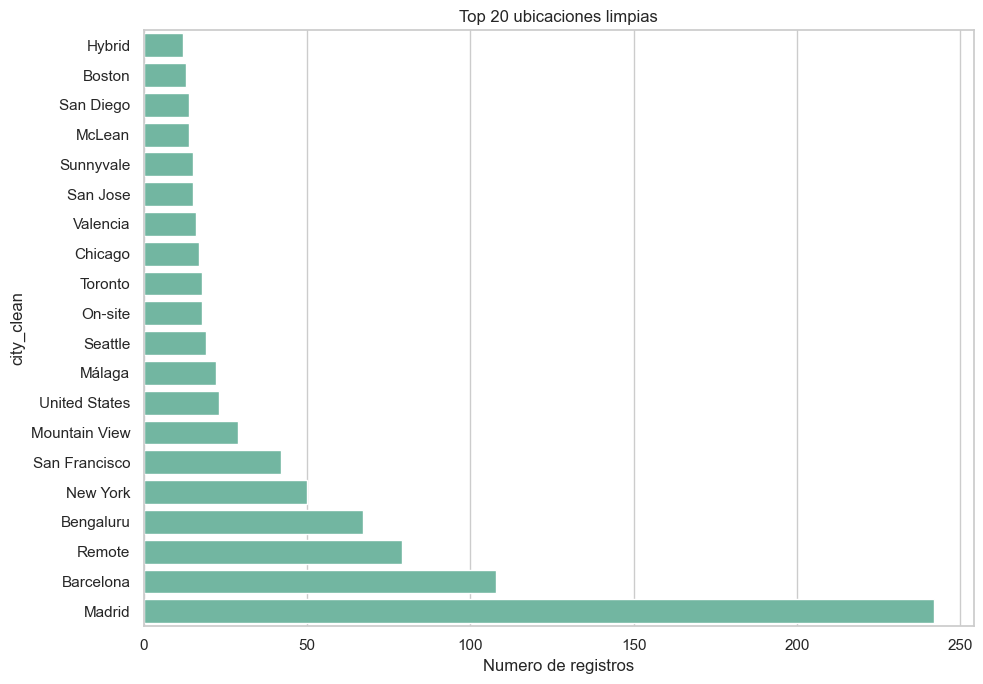

In [15]:
# Ciudades mas frecuentes / Most frequent cities
top_cities = show_top_values(jobs_eda, "city_clean", top_n=20)
plot_top_values(jobs_eda, "city_clean", "Top 20 ubicaciones limpias", top_n=20, figsize=(10, 7))

,is_remote,job_count,job_pct
0,False,1463,94.88
1,True,79,5.12


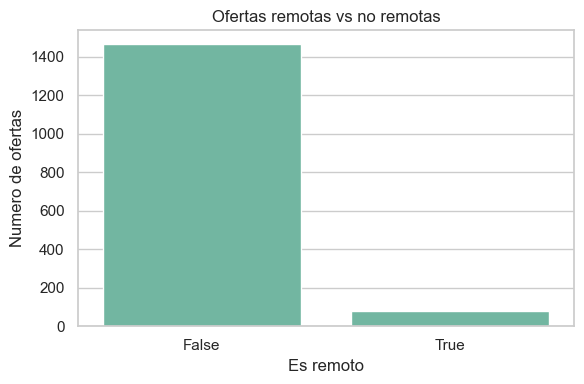

In [16]:
# Distribucion de trabajo remoto / Remote-work distribution
remote_distribution = (
    jobs_eda["is_remote"]
    .value_counts(dropna=False)
    .rename_axis("is_remote")
    .reset_index(name="job_count")
)

remote_distribution["job_pct"] = (
    remote_distribution["job_count"] / remote_distribution["job_count"].sum() * 100
).round(2)

display(remote_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(data=remote_distribution, x="is_remote", y="job_count")
plt.title("Ofertas remotas vs no remotas")
plt.xlabel("Es remoto")
plt.ylabel("Numero de ofertas")
plt.tight_layout()
plt.show()

,work_modality,job_count,job_pct
0,unknown,869,56.36
1,hybrid,417,27.04
2,remote,208,13.49
3,onsite,48,3.11


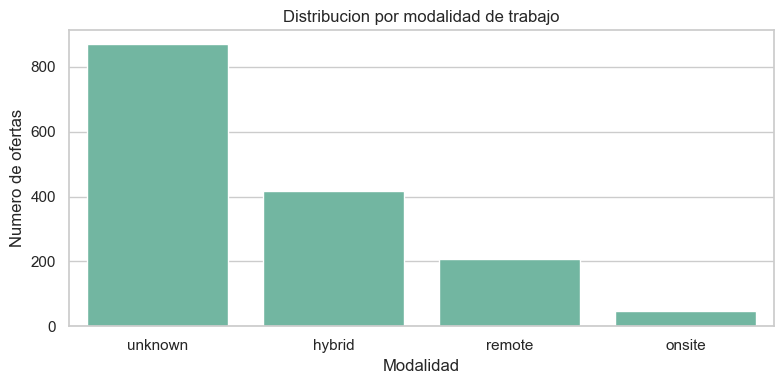

In [17]:
def classify_work_modality(row):
    """
    ES: Clasifica modalidad usando job_type, location e is_remote.
    EN: Classifies work modality using job_type, location and is_remote.
    """
    combined_text = " ".join([
        str(row.get("job_type", "")),
        str(row.get("location", "")),
        str(row.get("location_clean", ""))
    ]).lower()

    if row.get("is_remote") is True or "100% remoto" in combined_text or "remote" in combined_text or "remoto" in combined_text:
        return "remote"
    if "hibrido" in combined_text or "híbrido" in combined_text or "hybrid" in combined_text:
        return "hybrid"
    if "presencial" in combined_text or "onsite" in combined_text:
        return "onsite"

    return "unknown"


# Clasificar modalidad de trabajo / Classify work modality
jobs_eda["work_modality"] = jobs_eda.apply(classify_work_modality, axis=1)

work_modality_distribution = (
    jobs_eda["work_modality"]
    .value_counts()
    .rename_axis("work_modality")
    .reset_index(name="job_count")
)

work_modality_distribution["job_pct"] = (
    work_modality_distribution["job_count"] / work_modality_distribution["job_count"].sum() * 100
).round(2)

display(work_modality_distribution)

plt.figure(figsize=(8, 4))
sns.barplot(data=work_modality_distribution, x="work_modality", y="job_count")
plt.title("Distribucion por modalidad de trabajo")
plt.xlabel("Modalidad")
plt.ylabel("Numero de ofertas")
plt.tight_layout()
plt.show()

## 12. Seniority e industria

Se revisan las columnas de seniority e industria. Estas variables no están disponibles en todas las fuentes, por lo que se interpretan como información parcial.

,seniority_level,count
0,senior,629
1,lead,116
2,midlevel,112
3,junior,25


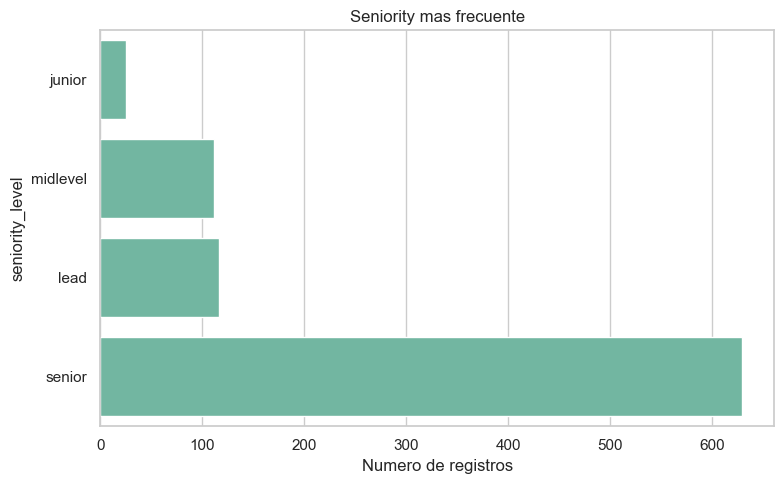

In [18]:
# Seniority mas frecuente / Most frequent seniority levels
show_top_values(jobs_eda, "seniority_level", top_n=15)
plot_top_values(jobs_eda, "seniority_level", "Seniority mas frecuente", top_n=15, figsize=(8, 5))

,industry,count
0,Technology,580
1,Finance,127
2,Retail,110
3,Healthcare,83
4,Education,19
5,Energy,12
6,Manufacturing,7
7,Logistics,4


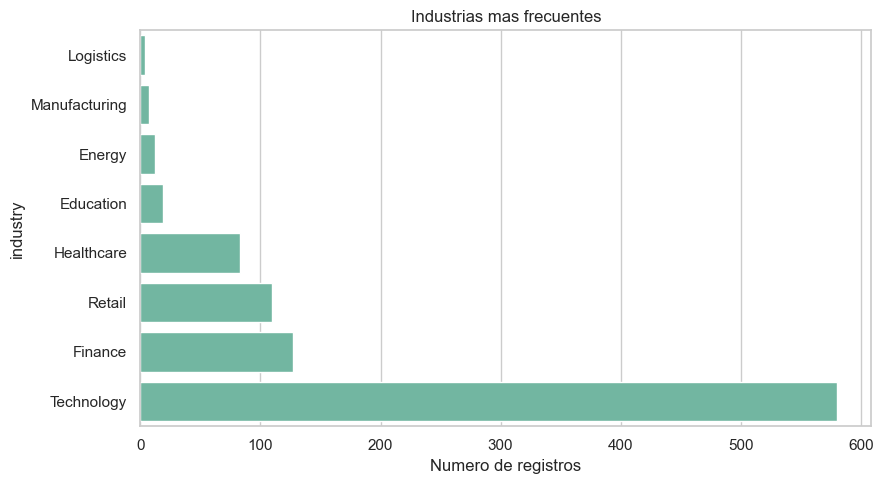

In [19]:
# Industrias mas frecuentes / Most frequent industries
show_top_values(jobs_eda, "industry", top_n=15)
plot_top_values(jobs_eda, "industry", "Industrias mas frecuentes", top_n=15, figsize=(9, 5))

## 13. Salarios

La columna `salary_clean` es una aproximación numérica creada durante el cleaning. No debe interpretarse como salario exacto, pero permite hacer una primera lectura de disponibilidad y distribución.

In [20]:
# Disponibilidad salarial / Salary availability
salary_availability = pd.DataFrame({
    "metric": ["total_jobs", "jobs_with_salary_clean", "jobs_without_salary_clean"],
    "value": [
        len(jobs_eda),
        jobs_eda["salary_clean"].notna().sum(),
        jobs_eda["salary_clean"].isna().sum()
    ]
})

salary_availability["pct"] = (salary_availability["value"] / len(jobs_eda) * 100).round(2)
display(salary_availability)

,metric,value,pct
0,total_jobs,1542,100.00
1,jobs_with_salary_clean,1071,69.46
2,jobs_without_salary_clean,471,30.54


,salary_clean
count,1.071000e+03
mean,1.161210e+05
std,1.282466e+05
min,1.700000e+01
25%,4.143050e+04
50%,1.193995e+05
75%,1.657745e+05
max,2.739979e+06


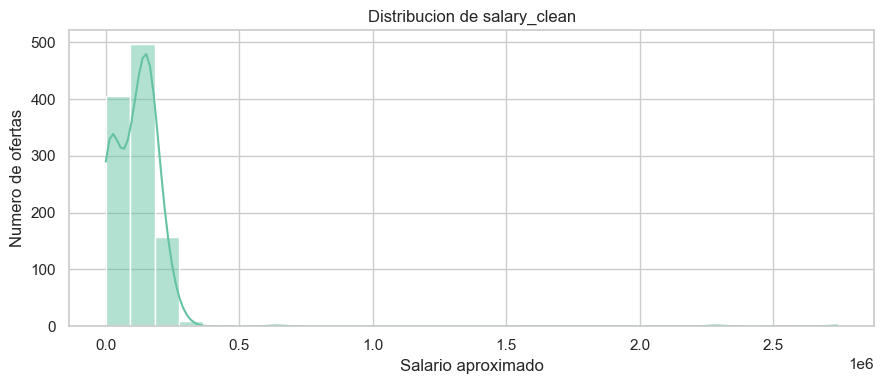

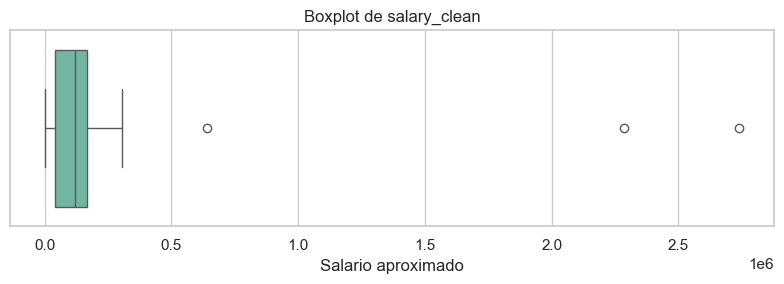

In [21]:
# Estadisticas descriptivas salariales / Salary descriptive statistics
salary_data = jobs_eda["salary_clean"].dropna()

if salary_data.empty:
    print("No hay suficientes datos salariales limpios para analizar.")
else:
    display(salary_data.describe().to_frame(name="salary_clean"))

    plt.figure(figsize=(9, 4))
    sns.histplot(salary_data, bins=30, kde=True)
    plt.title("Distribucion de salary_clean")
    plt.xlabel("Salario aproximado")
    plt.ylabel("Numero de ofertas")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 3))
    sns.boxplot(x=salary_data)
    plt.title("Boxplot de salary_clean")
    plt.xlabel("Salario aproximado")
    plt.tight_layout()
    plt.show()

In [22]:
# Salario por fuente y modalidad / Salary by source and modality
salary_by_source = (
    jobs_eda
    .dropna(subset=["salary_clean"])
    .groupby("source_dataset")
    .agg(
        jobs_with_salary=("job_id", "count"),
        median_salary=("salary_clean", "median"),
        mean_salary=("salary_clean", "mean")
    )
    .round(2)
    .reset_index()
)

display(salary_by_source)

salary_by_modality = (
    jobs_eda
    .dropna(subset=["salary_clean"])
    .groupby("work_modality")
    .agg(
        jobs_with_salary=("job_id", "count"),
        median_salary=("salary_clean", "median"),
        mean_salary=("salary_clean", "mean")
    )
    .round(2)
    .reset_index()
)

display(salary_by_modality)

,source_dataset,jobs_with_salary,median_salary,mean_salary
0,df_jobs,942,134766.0,132017.95
1,df_tecno,129,36.0,36.29


,work_modality,jobs_with_salary,median_salary,mean_salary
0,hybrid,256,115815.5,115077.93
1,onsite,13,24.0,28.65
2,remote,117,100469.0,96079.04
3,unknown,685,126960.0,122137.26


## 14. Skills de ofertas

`job_skills_long.csv` permite analizar skills en formato largo: una fila por oferta y skill. Esto facilita rankings y comparaciones con tecnologías de Stack Overflow.

,skill,count
0,python,639
1,machine learning,580
2,sql,441
3,r,343
4,aws,217
5,deep learning,178
6,tensorflow,165
7,spark,161
8,azure,154
9,pytorch,148


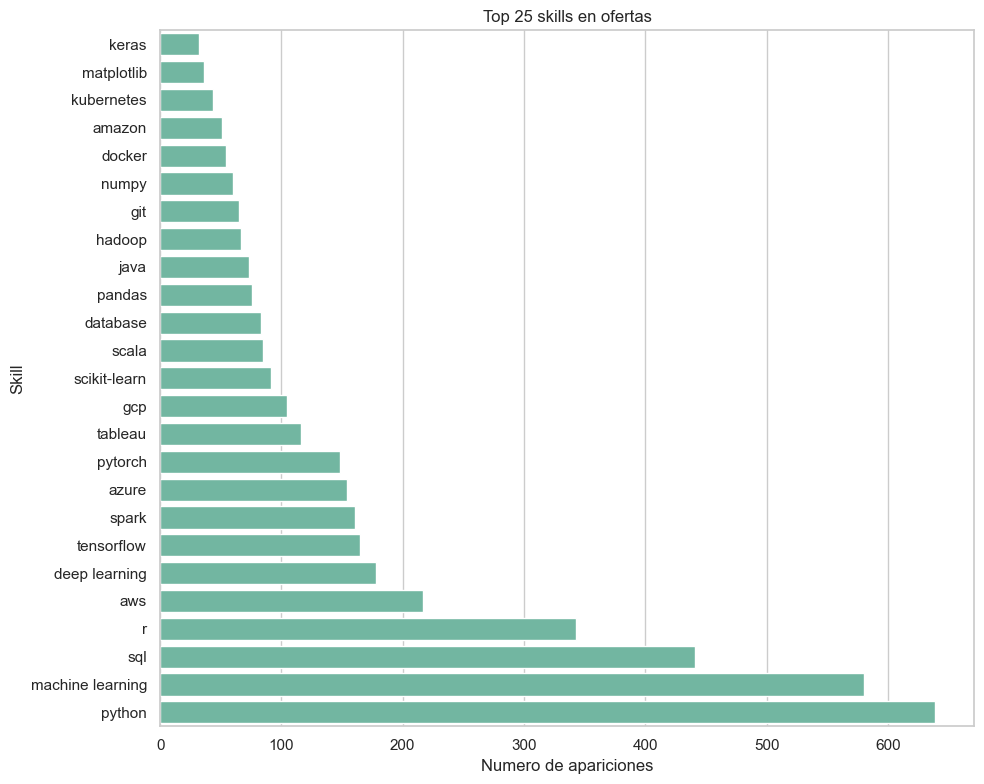

In [23]:
# Skills mas frecuentes en ofertas / Most frequent job skills
top_skills = (
    job_skills_long["skill"]
    .dropna()
    .astype(str)
    .value_counts()
    .head(25)
    .rename_axis("skill")
    .reset_index(name="count")
)

display(top_skills)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_skills.sort_values("count", ascending=True), x="count", y="skill")
plt.title("Top 25 skills en ofertas")
plt.xlabel("Numero de apariciones")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [24]:
# Skills por fuente / Skills by source
skills_by_source = (
    job_skills_long
    .groupby(["source_dataset", "skill"])
    .size()
    .reset_index(name="count")
    .sort_values(["source_dataset", "count"], ascending=[True, False])
)

top_skills_by_source = skills_by_source.groupby("source_dataset").head(10).reset_index(drop=True)
display(top_skills_by_source)

,source_dataset,skill,count
0,df_jobs,python,639
1,df_jobs,machine learning,580
2,df_jobs,sql,441
3,df_jobs,r,343
4,df_jobs,aws,217
5,df_jobs,deep learning,178
6,df_jobs,tensorflow,165
7,df_jobs,spark,161
8,df_jobs,azure,154
9,df_jobs,pytorch,148


## 15. Tecnologías de Stack Overflow

Los rankings de Stack Overflow permiten observar tecnologías usadas (`used`) y tecnologías deseadas (`wanted`). Esta información no representa ofertas de empleo, sino preferencias y experiencia declarada por profesionales.

In [25]:
# Rankings generales de tecnologias / General technology rankings
display(technology_rankings.head(20))

print("Categorias disponibles:")
print(technology_rankings["category"].dropna().unique())

,category,type,technology,count
0,ai_model_tool,used,openAI GPT (chatbot models),13424
1,ai_model_tool,used,Anthropic: Claude Sonnet,7063
2,ai_model_tool,used,Gemini (Flash general purpose models),5823
3,ai_model_tool,used,openAI Reasoning models,5716
4,ai_model_tool,used,openAI Image generating models,4395
5,ai_model_tool,used,Gemini (Pro Reasoning models),4221
6,ai_model_tool,used,DeepSeek (R- Reasoning models),3848
7,ai_model_tool,used,Meta Llama (all models),2941
8,ai_model_tool,used,DeepSeek (V- General purpose models),2363
9,ai_model_tool,used,X Grok models,1839


Categorias disponibles:
<StringArray>
[          'ai_model_tool',                'database',
 'development_environment',                'language',
          'platform_cloud',           'web_framework']
Length: 6, dtype: str


,category,type,technology,count
0,ai_model_tool,used,openAI GPT (chatbot models),13424
1,ai_model_tool,used,Anthropic: Claude Sonnet,7063
2,ai_model_tool,used,Gemini (Flash general purpose models),5823
3,ai_model_tool,used,openAI Reasoning models,5716
4,ai_model_tool,used,openAI Image generating models,4395
5,ai_model_tool,used,Gemini (Pro Reasoning models),4221
6,ai_model_tool,used,DeepSeek (R- Reasoning models),3848
7,ai_model_tool,used,Meta Llama (all models),2941
8,ai_model_tool,used,DeepSeek (V- General purpose models),2363
9,ai_model_tool,used,X Grok models,1839


,category,type,technology,count
0,ai_model_tool,wanted,openAI GPT (chatbot models),8328
1,ai_model_tool,wanted,Anthropic: Claude Sonnet,5428
2,ai_model_tool,wanted,openAI Reasoning models,4213
3,ai_model_tool,wanted,Gemini (Flash general purpose models),3865
4,ai_model_tool,wanted,Gemini (Pro Reasoning models),3670
5,ai_model_tool,wanted,openAI Image generating models,3031
6,ai_model_tool,wanted,DeepSeek (R- Reasoning models),2750
7,ai_model_tool,wanted,Meta Llama (all models),2004
8,ai_model_tool,wanted,DeepSeek (V- General purpose models),1832
9,ai_model_tool,wanted,X Grok models,1429


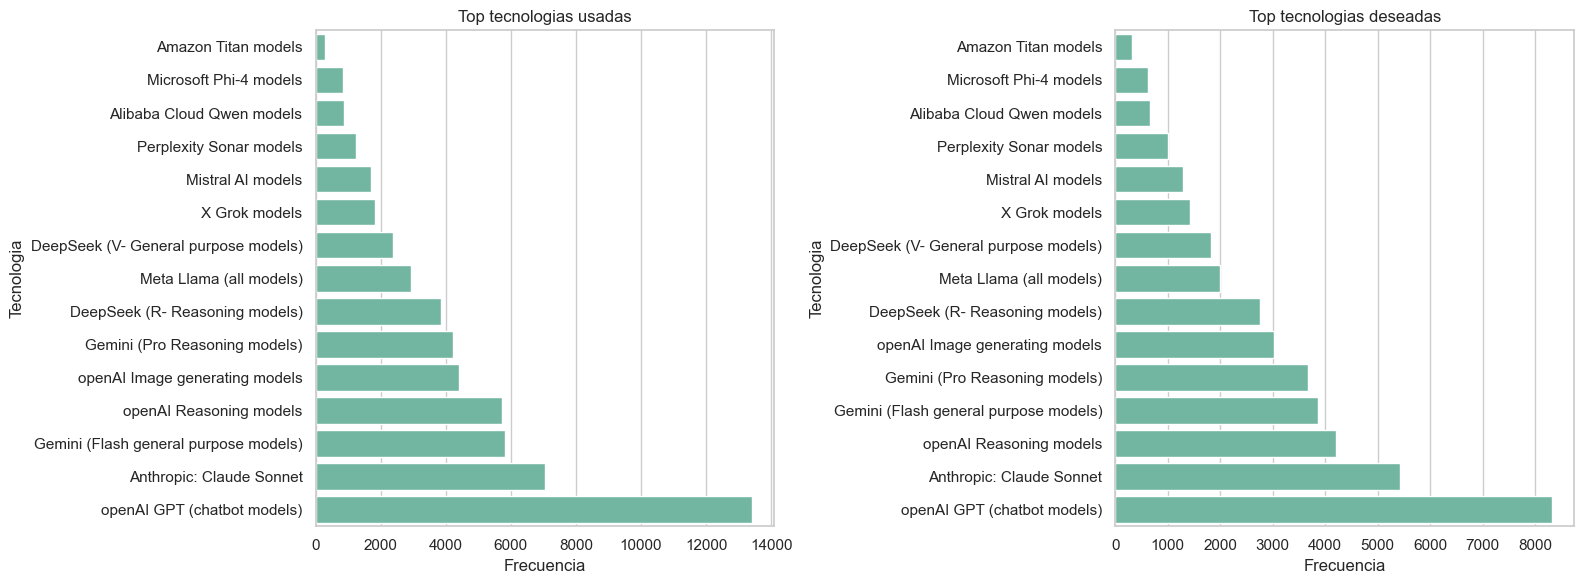

In [26]:
# Top tecnologias usadas y deseadas / Top used and wanted technologies
top_used_technologies = technology_rankings_used.head(15)
top_wanted_technologies = technology_rankings_wanted.head(15)

display(top_used_technologies)
display(top_wanted_technologies)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_used_technologies.sort_values("count", ascending=True),
    x="count",
    y="technology",
    ax=axes[0]
)
axes[0].set_title("Top tecnologias usadas")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Tecnologia")

sns.barplot(
    data=top_wanted_technologies.sort_values("count", ascending=True),
    x="count",
    y="technology",
    ax=axes[1]
)
axes[1].set_title("Top tecnologias deseadas")
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Tecnologia")

plt.tight_layout()
plt.show()

In [27]:
# Top tecnologias por categoria / Top technologies by category
technology_top_by_category = (
    technology_rankings
    .sort_values(["category", "type", "count"], ascending=[True, True, False])
    .groupby(["category", "type"])
    .head(5)
    .reset_index(drop=True)
)

display(technology_top_by_category)

,category,type,technology,count
0,ai_model_tool,used,openAI GPT (chatbot models),13424
1,ai_model_tool,used,Anthropic: Claude Sonnet,7063
2,ai_model_tool,used,Gemini (Flash general purpose models),5823
3,ai_model_tool,used,openAI Reasoning models,5716
4,ai_model_tool,used,openAI Image generating models,4395
5,ai_model_tool,wanted,openAI GPT (chatbot models),8328
6,ai_model_tool,wanted,Anthropic: Claude Sonnet,5428
7,ai_model_tool,wanted,openAI Reasoning models,4213
8,ai_model_tool,wanted,Gemini (Flash general purpose models),3865
9,ai_model_tool,wanted,Gemini (Pro Reasoning models),3670


## 16. Comparación inicial entre skills y tecnologías

Se realiza una comparación simple entre las skills más frecuentes en ofertas y las tecnologías más frecuentes en Stack Overflow. Esta comparación es aproximada porque las fuentes tienen naturalezas distintas y los nombres no siempre coinciden exactamente.

In [28]:
# Comparacion simple por nombre normalizado / Simple comparison by normalized name
top_job_skill_names = set(top_skills["skill"].apply(normalize_text_value))
top_wanted_technology_names = set(
    technology_rankings_wanted.head(50)["technology"].apply(normalize_text_value)
)
top_used_technology_names = set(
    technology_rankings_used.head(50)["technology"].apply(normalize_text_value)
)

skill_technology_overlap = pd.DataFrame({
    "comparison": [
        "top_job_skills_vs_top_wanted_technologies",
        "top_job_skills_vs_top_used_technologies"
    ],
    "overlap_count": [
        len(top_job_skill_names.intersection(top_wanted_technology_names)),
        len(top_job_skill_names.intersection(top_used_technology_names))
    ],
    "overlap_values": [
        ", ".join(sorted(top_job_skill_names.intersection(top_wanted_technology_names))),
        ", ".join(sorted(top_job_skill_names.intersection(top_used_technology_names)))
    ]
})

display(skill_technology_overlap)

,comparison,overlap_count,overlap_values
0,top_job_skills_vs_top_wanted_technologies,0,
1,top_job_skills_vs_top_used_technologies,0,


## 17. Fechas de publicación

Se revisa la columna `post_date` para entender si las ofertas se concentran en ciertos días o meses. Las fechas proceden de fuentes distintas, por lo que se parsean con cautela.

In [29]:
# Convertir fechas con dayfirst porque TecnoEmpleo usa formato dd/mm/yyyy / Parse dates with dayfirst because TecnoEmpleo uses dd/mm/yyyy
jobs_eda["post_date_parsed"] = pd.to_datetime(jobs_eda["post_date"], errors="coerce", dayfirst=True)

post_date_summary = pd.DataFrame({
    "metric": ["valid_dates", "missing_or_invalid_dates", "min_date", "max_date"],
    "value": [
        jobs_eda["post_date_parsed"].notna().sum(),
        jobs_eda["post_date_parsed"].isna().sum(),
        jobs_eda["post_date_parsed"].min(),
        jobs_eda["post_date_parsed"].max()
    ]
})

display(post_date_summary)

C:\Users\User\AppData\Local\Temp\ipykernel_31448\911424086.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  jobs_eda["post_date_parsed"] = pd.to_datetime(jobs_eda["post_date"], errors="coerce", dayfirst=True)


,metric,value
0,valid_dates,600
1,missing_or_invalid_dates,942
2,min_date,2026-04-01 00:00:00
3,max_date,2026-04-04 00:00:00


,post_month,source_dataset,job_count
0,2026-04,df_tecno,600


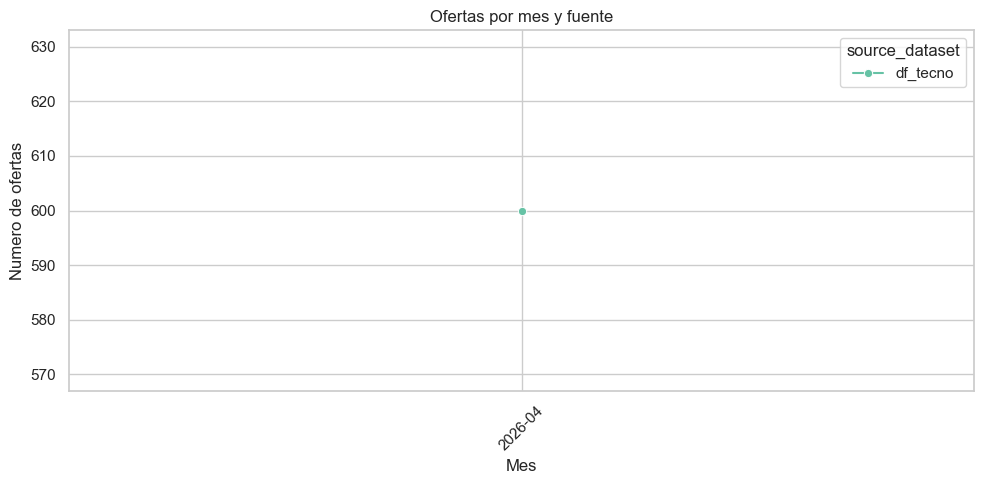

In [30]:
# Ofertas por mes / Job postings by month
jobs_eda["post_month"] = jobs_eda["post_date_parsed"].dt.to_period("M").astype(str)
monthly_jobs = (
    jobs_eda[jobs_eda["post_date_parsed"].notna()]
    .groupby(["post_month", "source_dataset"])
    .size()
    .reset_index(name="job_count")
)

display(monthly_jobs.head(20))

if monthly_jobs.empty:
    print("No hay fechas validas suficientes para graficar.")
else:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly_jobs, x="post_month", y="job_count", hue="source_dataset", marker="o")
    plt.title("Ofertas por mes y fuente")
    plt.xlabel("Mes")
    plt.ylabel("Numero de ofertas")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 18. Limitaciones detectadas

Durante el EDA se deben tener en cuenta estas limitaciones:

- Las fuentes no representan exactamente el mismo universo: unas son ofertas de empleo y otra procede de respuestas de Stack Overflow.
- Algunas columnas tienen muchos valores nulos, especialmente salario, skills, industria y seniority en ciertas fuentes.
- `salary_clean` es una aproximación numérica, no un salario exacto.
- La clasificación de familias de rol y modalidad se basa en reglas simples de texto.
- La comparación entre skills de ofertas y tecnologías de Stack Overflow es orientativa.

## 19. Conclusiones iniciales

La siguiente celda resume de forma automática algunos hallazgos básicos del EDA. Estas conclusiones sirven como punto de partida para el notebook de visualizaciones y para el análisis final.

In [31]:
# Generar resumen automatico de conclusiones / Generate automatic summary of findings
main_source = source_distribution.sort_values("job_count", ascending=False).iloc[0]
main_family = job_family_distribution.sort_values("job_count", ascending=False).iloc[0]
main_city = top_cities.iloc[0] if not top_cities.empty else None
main_modality = work_modality_distribution.sort_values("job_count", ascending=False).iloc[0]
salary_available_pct = salary_availability.loc[
    salary_availability["metric"] == "jobs_with_salary_clean",
    "pct"
].iloc[0]
main_skill = top_skills.iloc[0] if not top_skills.empty else None
main_wanted_technology = technology_rankings_wanted.iloc[0] if not technology_rankings_wanted.empty else None

print("Conclusiones iniciales del EDA")
print("-" * 35)
print(f"1. El dataset unificado original contiene {len(jobs_all_clean)} ofertas y {jobs_all_clean.shape[1]} columnas.")
print(f"2. La copia de trabajo del EDA contiene {jobs_eda.shape[1]} columnas tras crear variables auxiliares.")
print(f"3. La fuente con mas ofertas es {main_source['source_dataset']} con {main_source['job_count']} registros ({main_source['job_pct']}%).")
print(f"4. La familia de rol mas frecuente es {main_family['job_family']} con {main_family['job_count']} ofertas ({main_family['job_pct']}%).")

if main_city is not None:
    print(f"5. La ubicacion limpia mas frecuente es {main_city['city_clean']} con {main_city['count']} ofertas.")
else:
    print("5. No hay ubicaciones limpias suficientes para destacar una ciudad principal.")

print(f"6. La modalidad mas frecuente es {main_modality['work_modality']} con {main_modality['job_count']} ofertas ({main_modality['job_pct']}%).")
print(f"7. El porcentaje de ofertas con salary_clean disponible es {salary_available_pct}%.")

if main_skill is not None:
    print(f"8. La skill mas frecuente en ofertas es {main_skill['skill']} con {main_skill['count']} apariciones.")
else:
    print("8. No hay skills suficientes para destacar una skill principal.")

if main_wanted_technology is not None:
    print(f"9. La tecnologia mas deseada en Stack Overflow es {main_wanted_technology['technology']} dentro de {main_wanted_technology['category']}.")
else:
    print("9. No hay ranking de tecnologias deseadas disponible.")

Conclusiones iniciales del EDA
-----------------------------------
1. El dataset unificado original contiene 1542 ofertas y 17 columnas.
2. La copia de trabajo del EDA contiene 21 columnas tras crear variables auxiliares.
3. La fuente con mas ofertas es df_jobs con 942 registros (61.09%).
4. La familia de rol mas frecuente es data_science_ai con 942 ofertas (61.09%).
5. La ubicacion limpia mas frecuente es Madrid con 242 ofertas.
6. La modalidad mas frecuente es unknown con 869 ofertas (56.36%).
7. El porcentaje de ofertas con salary_clean disponible es 69.46%.
8. La skill mas frecuente en ofertas es python con 639 apariciones.
9. La tecnologia mas deseada en Stack Overflow es openAI GPT (chatbot models) dentro de ai_model_tool.


## 20. Próximos pasos

A partir de este EDA, el siguiente paso natural es construir visualizaciones más cuidadas en `04_visualizations.ipynb`, priorizando:

- Distribución de ofertas por fuente.
- Roles y familias de rol más frecuentes.
- Ubicaciones y modalidad de trabajo.
- Disponibilidad y distribución salarial.
- Skills más demandadas.
- Tecnologías usadas y deseadas según Stack Overflow.

Estas visualizaciones deberían apoyarse en las columnas ya unificadas durante el cleaning para mantener consistencia en todo el proyecto.